<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#The-SVI-parametrization" data-toc-modified-id="The-SVI-parametrization-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>The SVI parametrization</a></span><ul class="toc-item"><li><span><a href="#Implementing-the-parametrization" data-toc-modified-id="Implementing-the-parametrization-1.1"><span class="toc-item-num">1.1&nbsp;&nbsp;</span>Implementing the parametrization</a></span></li><li><span><a href="#Plotting-SVI-implied-volatility" data-toc-modified-id="Plotting-SVI-implied-volatility-1.2"><span class="toc-item-num">1.2&nbsp;&nbsp;</span>Plotting SVI implied volatility</a></span></li><li><span><a href="#Test-if-butterfly-arbitrage" data-toc-modified-id="Test-if-butterfly-arbitrage-1.3"><span class="toc-item-num">1.3&nbsp;&nbsp;</span>Test if butterfly arbitrage</a></span></li><li><span><a href="#Usual-Black-Scholes-functions" data-toc-modified-id="Usual-Black-Scholes-functions-1.4"><span class="toc-item-num">1.4&nbsp;&nbsp;</span>Usual Black-Scholes functions</a></span></li></ul></li><li><span><a href="#An-example-of-SVI-calibration-with-synthetic-data" data-toc-modified-id="An-example-of-SVI-calibration-with-synthetic-data-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>An example of SVI calibration with synthetic data</a></span><ul class="toc-item"><li><span><a href="#Data" data-toc-modified-id="Data-2.1"><span class="toc-item-num">2.1&nbsp;&nbsp;</span>Data</a></span></li><li><span><a href="#Plotting" data-toc-modified-id="Plotting-2.2"><span class="toc-item-num">2.2&nbsp;&nbsp;</span>Plotting</a></span></li><li><span><a href="#Fit-an-SVI-parameterisation" data-toc-modified-id="Fit-an-SVI-parameterisation-2.3"><span class="toc-item-num">2.3&nbsp;&nbsp;</span>Fit an SVI parameterisation</a></span></li></ul></li><li><span><a href="#An-example-of-SVI-calibration-on-real-data-(OESB,--2021-Feb.-19th)" data-toc-modified-id="An-example-of-SVI-calibration-on-real-data-(OESB,--2021-Feb.-19th)-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>An example of SVI calibration on real data (OESB,  2021 Feb. 19th)</a></span></li></ul></div>

# The SVI parametrization

We remind the SVI parameterization by [Gatheral 2004] for the smile of implicit total variance at given maturity $\tau$:

\begin{equation}
w_\mathrm{SVI}(k) = a + b \left(\rho (k - k_0) + \sqrt{(k - k_0)^2 + \sigma^2} \right)
\qquad k \in \mathbb R,
\end{equation}

where $k = \log \frac K {F(0, \tau)}$ is the log-forward moneyness variable and the function $w_\mathrm{SVI}(k) = \tau \, I^2_{0}(k, \tau)$ represents the implicit total variance (equal to implicit vol$^2$ $\times$ maturity).

The conditions for positivity and increasingness in the wings are 
\begin{align*}
&\sigma>0,&&
b>0,\\
&\rho\in[-1,1],&&
a+b\sigma \sqrt{1-\rho^2}>0,\\
&b (1+|\rho|)\leq  {2}{}.&&
\end{align*}


We often call the above function "SVI slice", because this is the parameterization of a single smile at given maturity (that we see as a "slice" of the whole implicit variance surface).

## Implementing the parametrization

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def SVI(k, a, b , rho, k_0, sig):
    total_variance = a + b*( rho*(k - k_0) + np.sqrt( (k - k_0)*(k - k_0) + sig*sig) )    
    return total_variance

In [3]:
############################################
# A set of SVI parameters : expiry 3 months
############################################
tau= 3/12.0
a_true = 0.02 # 0.008
b_true = 0.2
rho_true = -.3
k_0_true = 0.05
sig_true = 0.6
lm_min, lm_max = -1, 1 # available range of log moneyness

## Plotting SVI implied volatility

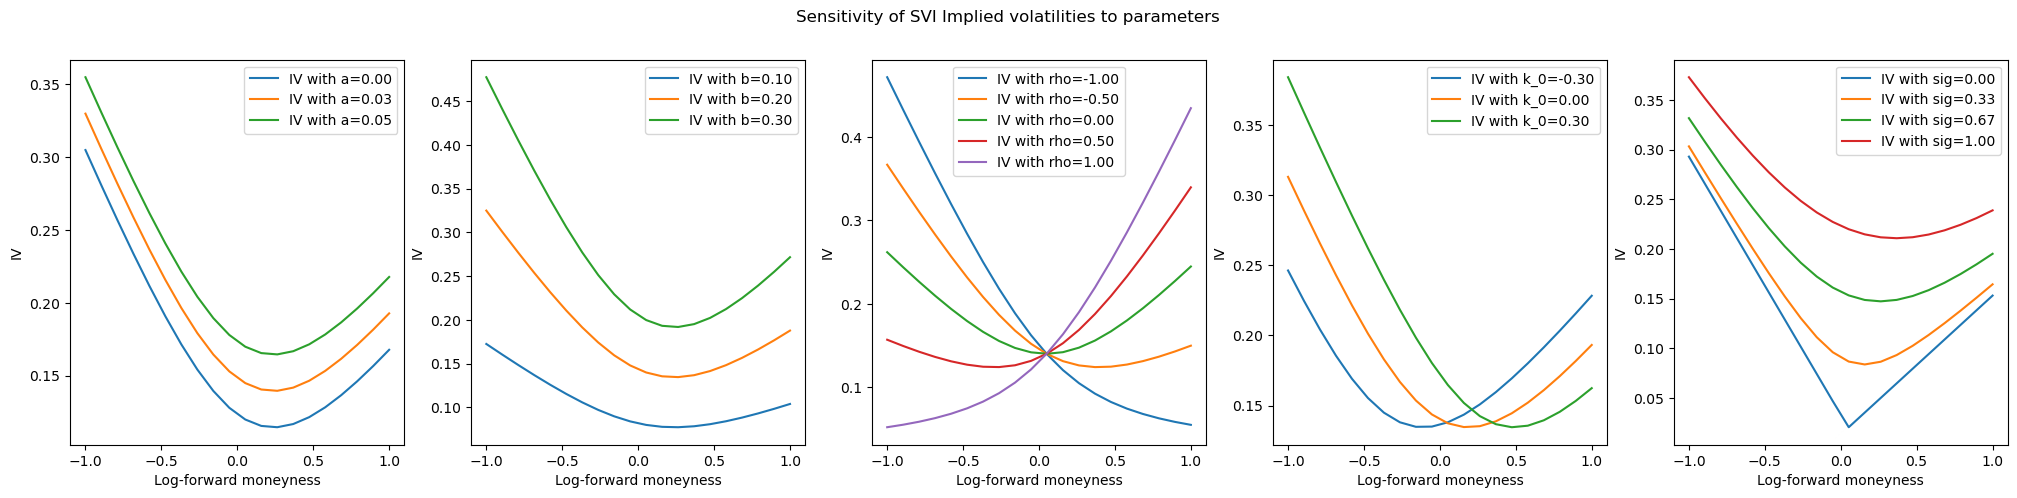

In [4]:
lm_grid = np.linspace(lm_min, lm_max, 20)
fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(1, 5, figsize=(25, 5))
fig.suptitle('Sensitivity of SVI Implied volatilities to parameters')

for a in np.linspace(0.0,0.05,3):
    ax1.plot(lm_grid, SVI(lm_grid, a=a, b=b_true , rho=rho_true, k_0=k_0_true, sig=sig_true), label="IV with a=%1.2f"%a)
ax1.set_xlabel('Log-forward moneyness')
ax1.set_ylabel('IV')
ax1.legend()

for b in np.linspace(0.1,0.3,3):
    ax2.plot(lm_grid, SVI(lm_grid, a=a_true, b=b , rho=rho_true, k_0=k_0_true, sig=sig_true), label="IV with b=%1.2f"%b)
ax2.set_xlabel('Log-forward moneyness')
ax2.set_ylabel('IV')
ax2.legend()

for rho in np.linspace(-1,1,5):
    ax3.plot(lm_grid, SVI(lm_grid, a=a_true, b=b_true , rho=rho, k_0=k_0_true, sig=sig_true), label="IV with rho=%1.2f"%rho)
ax3.set_xlabel('Log-forward moneyness')
ax3.set_ylabel('IV')
ax3.legend()

for k_0 in np.linspace(-0.3,0.3,3):
    ax4.plot(lm_grid, SVI(lm_grid, a=a_true, b=b_true , rho=rho_true, k_0=k_0, sig=sig_true), label="IV with k_0=%1.2f"%k_0)
ax4.set_xlabel('Log-forward moneyness')
ax4.set_ylabel('IV')
ax4.legend()

for sig in np.linspace(0.0,1,4):
    ax5.plot(lm_grid, SVI(lm_grid, a=a_true, b=b_true , rho=rho_true, k_0=k_0_true, sig=sig), label="IV with sig=%1.2f"%sig)
ax5.set_xlabel('Log-forward moneyness')
ax5.set_ylabel('IV')
ax5.legend()

plt.show()    

## Test if butterfly arbitrage

The absence of butterfly arbitrage (call/put prices are convex in strike) is equivalent to 
$$g(k):=\left(1-\frac{k \partial_k w(k,\tau)}{2 w(k,\tau)}\right)^2-\frac {(\partial_k w(k,\tau))^2}{4}\left(\frac{1}{ w(k,\tau)}+\frac{1}{4 }\right)+\frac{ \partial^2_{kk}w(k,\tau)}2\geq0,$$
for any $k\in \mathbb R$, and to $$\lim_{k\to +\infty} \left(-\frac{k}{\sqrt{w(k,\tau)} }+\frac{1}{2 }\sqrt{w(k,\tau)}\right)=-\infty.$$
These two conditions are written on the total implicit variance for a given time-to-maturity $\tau$.

In [5]:
def g_SVI(k, a, b , rho, k_0, sig): # we compute the function g in the SVI model
    w=SVI(k, a, b , rho, k_0, sig)
    derivee_w= b * (rho+ (k-k_0) / np.sqrt((k-k_0)**2+sig**2) )
    derivee_seconde_w= b/np.sqrt((k-k_0)**2 +sig**2 )- b * (k-k_0)**2 /(np.sqrt((k-k_0)**2+sig**2))**3
    value_g=(1-k*derivee_w/(2*w))**2 - (derivee_w)**2/4 * (1/w + 1/4) + derivee_seconde_w/2
    return value_g

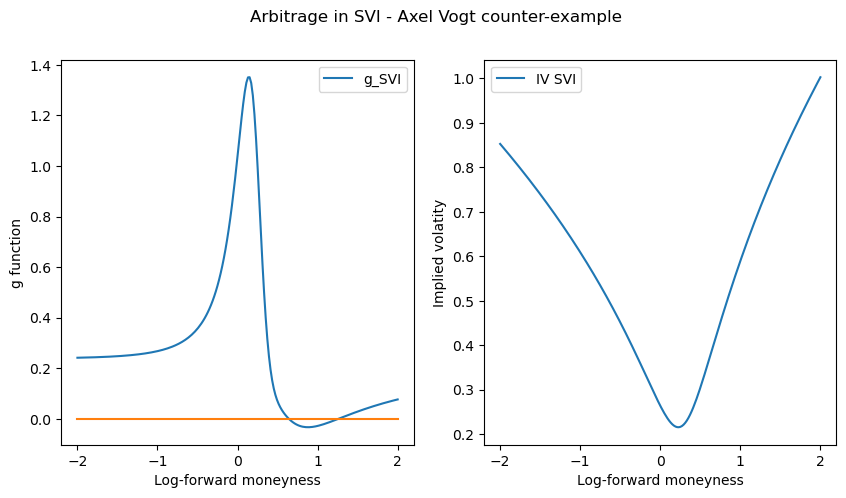

In [6]:
# Axel Vogt counter-example
# this smile is not free of butterfly arbitrage
a, b, k_0, rho, sig = -0.0410, 0.1331, 0.3586, 0.3060, 0.4153
lm_grid_test=np.linspace(-2,2,200)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('Arbitrage in SVI - Axel Vogt counter-example')

# plot of g function
ax1.plot(lm_grid_test, g_SVI(lm_grid_test, a, b , rho, k_0, sig), label="g_SVI")
ax1.plot(lm_grid_test, 0 *lm_grid_test)
ax1.set_xlabel('Log-forward moneyness')
ax1.set_ylabel('g function')
ax1.legend()

# implied volatility 
ax2.plot(lm_grid_test, np.sqrt(SVI(lm_grid_test, a, b , rho, k_0, sig)/tau), label="IV SVI")
ax2.set_xlabel('Log-forward moneyness')
ax2.set_ylabel('Implied volatity')
ax2.legend()

## Usual Black-Scholes functions

In [7]:
import scipy.stats as sps

def Call_BS_core(tau, K, DF, F, sigma):
    """
    Prix du Call Black-Scholes en fonction de
    tau   : time to maturity
    K     : strike
    DF    : discount factor. DF = e^{-r*tau} si taux d'intérêt déterministe r.
    F     : prix forward du sous-jacent
    sigma : volatilité
    """
    sigma_sqrt_tau = sigma * np.sqrt(tau)
    d_plus = np.log(F/K)/sigma_sqrt_tau + sigma_sqrt_tau/2.
    d_minus = d_plus - sigma_sqrt_tau
    prix_call = DF * (F * sps.norm.cdf(d_plus) - K * sps.norm.cdf(d_minus))
    return prix_call

def Put_BS_core(tau, K, DF, F, sigma):
    """
    Prix du Put Black-Scholes en fonction de
    tau   : time to maturity
    K     : strike
    DF    : discount factor. DF = e^{-r*tau} si taux d'intérêt déterministe r.
    F     : prix forward du sous-jacent
    sigma : volatilité
    """
    prix_put=Call_BS_core(tau, K, DF, F, sigma) - DF * (F - K)
    return prix_put

def Vega_core(tau, K, DF, F, sigma):
    """
    Vega d'un call Black-Scholes en fonction de
    tau   : time to maturity
    K     : strike
    DF    : discount factor. DF = e^{-r*tau} si taux d'intérêt déterministe r.
    F     : prix forward du sous-jacent
    sigma : volatilité
    """
    sigma_sqrt_tau = sigma * np.sqrt(tau)
    d_plus = np.log(F/K) / sigma_sqrt_tau + sigma_sqrt_tau / 2.
    vega = DF * F * np.sqrt(tau) * np.exp(-d_plus**2 / 2) / np.sqrt(2*np.pi)
    return vega

def volImplCallCore_Newton(tau, K, DF, F, target_price, initial_point='automatic', prix_tol = 1.e-3, max_iter=50):
    """
    Volatilité implicite d'un Call de prix = target_price, lorsque les autres paramètres sont:
    tau   : time to maturity
    K     : strike
    DF    : discount factor. DF = e^{-r*tau} si taux d'intérêt déterministe r.
    F     : prix forward du sous-jacent
    Méthode: Newton.
    """
    if initial_point == 'automatic':
        vol = np.sqrt( 2/tau * np.abs(np.log(F/K)) )
    else:
        vol = initial_point
    current_price = Call_BS_core(tau, K, DF, F, vol)
    critere_arret = np.abs(current_price - target_price)
    iterations = 0
    while ( (critere_arret > prix_tol) & (iterations < max_iter) ):
        iterations = iterations + 1
        vol = vol - (current_price - target_price) / Vega_core(tau, K, DF, F, vol)
        current_price = Call_BS_core(tau, K, DF, F, vol)
        critere_arret = np.abs(current_price - target_price)
    return vol, iterations

In [8]:
###############
## Sanity check
###############
T = 0.5; K = 115; t = 0; sigma = 0.3; r = 0.02; q = 0.03; S= 100

tau = T - t
DF = np.exp(-r*tau)
F = S * np.exp((r-q)*tau)

call_price = Call_BS_core(tau, K, DF, F, sigma)
vol_impli, iterations=volImplCallCore_Newton(tau, K, DF, F, call_price, initial_point='automatic', prix_tol = 1.e-3, max_iter=50)

print("Call price:",call_price)
print("vol_impli=%f, iterations=%d"%(vol_impli, iterations))

Call price: 3.2962105015149765
vol_impli=0.300000, iterations=3


## Find an arbitrage in the Vogt parameters
We are looking for $K_{\rm left}$ and $K_{\rm right}$ such that 
$$Call\left(T,\frac{K_{\rm left}+K_{\rm right}}2\right)> \frac 12\left(Call(T,K_{\rm left})+Call(T,K_{\rm right})\right).$$
This is a butterfly arbitrage!!

In [9]:
F, DF =1, 1
lm_grid_g_negative=lm_grid_test[g_SVI(lm_grid_test, a, b , rho, k_0, sig)<0]

lm_left, lm_right= lm_grid_g_negative[0], lm_grid_g_negative[-1]
K_left=F*np.exp(lm_left)
K_right=F*np.exp(lm_right)
K_mid=(K_left+K_right)/2
lm_mid=np.log(K_mid/F)

IV_lm_left=np.sqrt(SVI(lm_left, a, b , rho, k_0, sig)/tau)
IV_lm_right=np.sqrt(SVI(lm_right, a, b , rho, k_0, sig)/tau)
IV_lm_mid=np.sqrt(SVI(lm_mid, a, b , rho, k_0, sig)/tau)

Arbitrage=Call_BS_core(tau, K_mid, DF, F, IV_lm_mid)-0.5*(Call_BS_core(tau, K_left, DF, F, IV_lm_left)+Call_BS_core(tau, K_right, DF, F, IV_lm_right))
print("Butterfly arbitrage = ", Arbitrage, "> 0 !!")


Butterfly arbitrage =  8.916236823707869e-06 > 0 !!


# An example of SVI calibration with synthetic data
We consider that call-put market prices are given by a SVI model.

## Data

In [10]:
DF, F = 1, 1
lm_grid = np.linspace(lm_min, lm_max, 20)
call_prices = []
put_prices = []
IV_data = []
for lm in lm_grid: 
    sigma= np.sqrt( SVI(lm, a_true, b_true, rho_true, k_0_true, sig_true) / tau )
    IV_data=np.append(IV_data, sigma)
    call_prices=np.append(call_prices, Call_BS_core(tau=tau, K=F*np.exp(lm), DF=DF, F=F, sigma=sigma))
    put_prices=np.append(put_prices, Put_BS_core(tau=tau, K=F*np.exp(lm), DF=DF, F=F, sigma=sigma))

## Plotting

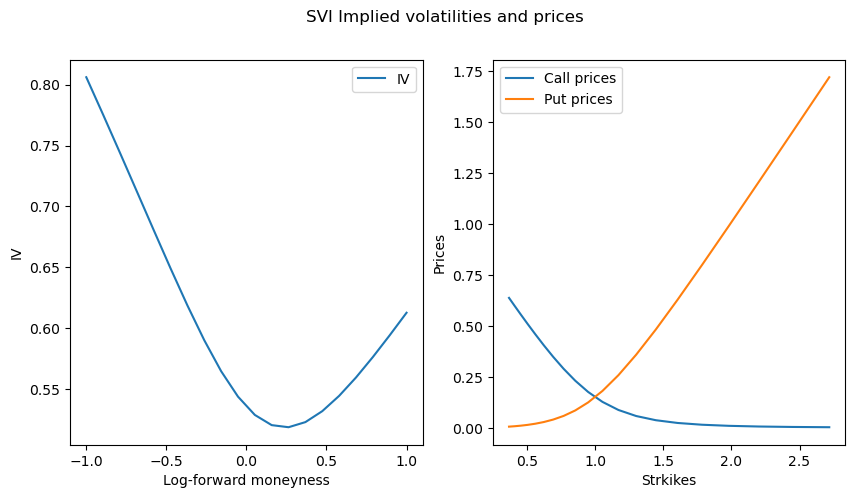

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('SVI Implied volatilities and prices')

ax1.plot(lm_grid, IV_data, label="IV")
ax1.set_xlabel('Log-forward moneyness')
ax1.set_ylabel('IV')
ax1.legend()

ax2.plot(F*np.exp(lm_grid), call_prices, label="Call prices")
ax2.plot(F*np.exp(lm_grid), put_prices, label="Put prices")
ax2.set_xlabel('Strkikes')
ax2.set_ylabel('Prices')
ax2.legend()

plt.show()    

## Fit an SVI parameterisation

The calibration problem we want to solve is a least-square problem:

$$
\min_{\Theta}
\sum_{i} \left( w^{\mathrm{mkt}}(k_i) - w_\mathrm{SVI} \left(k_i, \Theta \right) \right)^2
$$

where $w^{\mathrm{mkt}}(k_i) = \tau \left( I^{\mathrm{mkt}}(k_i) \right)^2$ are the market quotes for total implied variance, and $\Theta = (a,b,\rho,k_0,\sigma)$ is the vector of SVI parameters.

In [12]:
def function_to_minimize_least_squares(x, datalogfm, datavariancetotal): # la fonction à minimiser comme fonction de x de dimension 5
    tmp=0
    for j in range(len(datalogfm)):
        tmp=tmp+(datavariancetotal[j]-SVI(datalogfm[j], a=x[0], b=x[1] , rho=x[2], k_0=x[3], sig=x[4]))**2
    return tmp

Initial [0.06727914 0.         0.         0.         0.06727914]
Final [ 0.02000149  0.19999895 -0.29999777  0.05000406  0.59999469]
True (0.02, 0.2, -0.3, 0.05, 0.6)


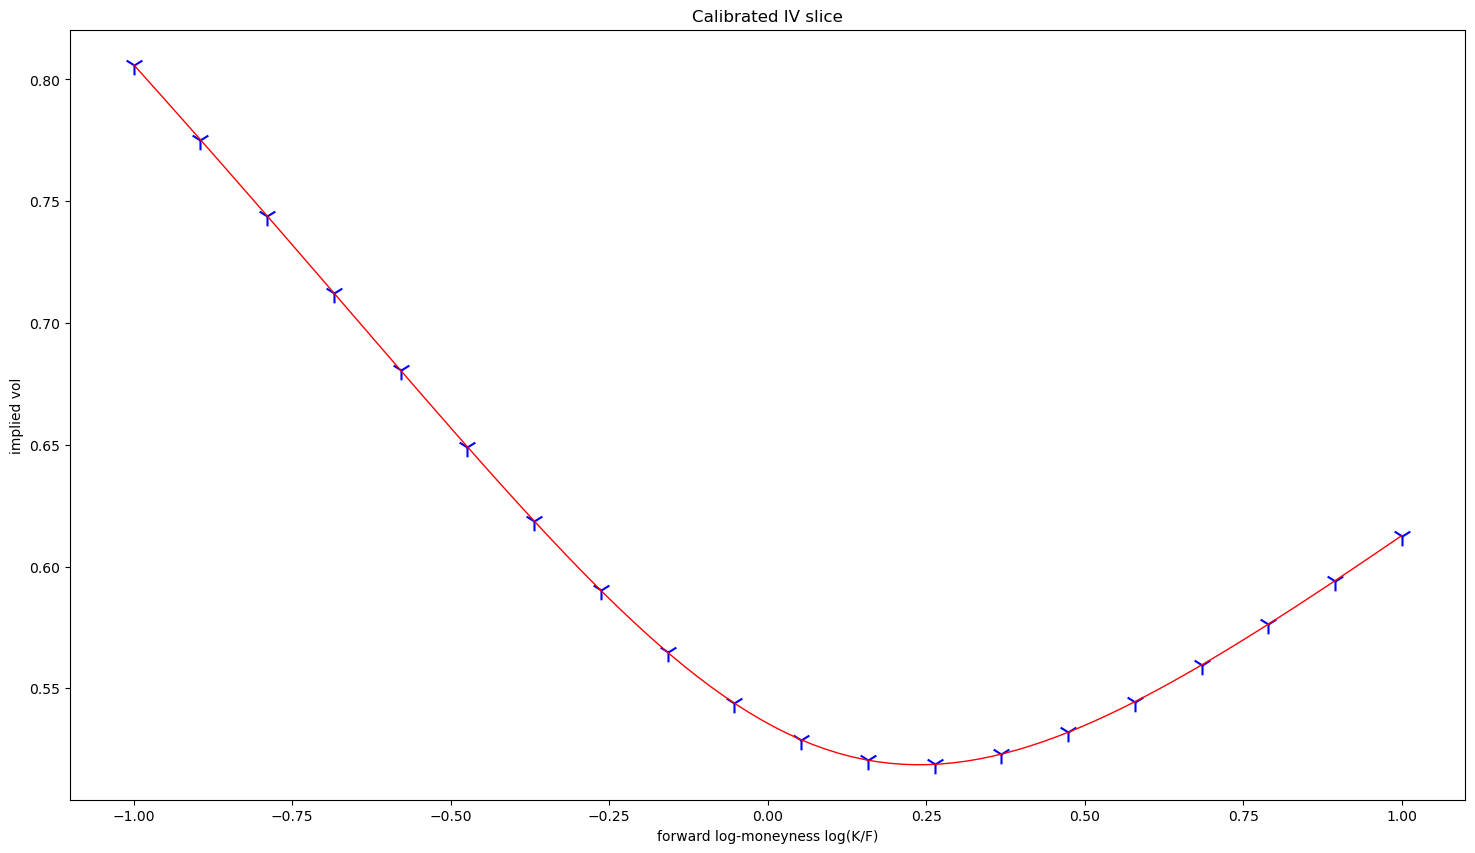

In [13]:
import scipy.optimize as optimization

# initial guess
a_init = np.min(IV_data**2*tau) /2
b_init = 0
rho_init = 0
k_0_init = 0 
sig_init = np.min(IV_data**2*tau) /2
SVIparameter_init    = np.array([a_init, b_init, rho_init, k_0_init, sig_init]) 

Total_Variance_data = IV_data**2*tau

result=optimization.minimize(function_to_minimize_least_squares, args=(lm_grid, Total_Variance_data), 
                             x0=SVIparameter_init, method='L-BFGS-B', tol=1E-10,
                             bounds=[(1E-5, np.max(Total_Variance_data)),
                                     (1E-3,1), 
                                     (-1 + 1e-3, 1 - 1e-3), 
                                     (2*np.min(lm_grid),2*np.max(lm_grid)), 
                                     (0.001, 1)])  

a, b , rho, k_0, sig = result['x']
print("Initial", SVIparameter_init)
print("Final", result['x'])
print("True", (a_true, b_true , rho_true, k_0_true, sig_true))

plt.figure(figsize=(18,10))
plt.title("Calibrated IV slice")
plt.xlabel("forward log-moneyness log(K/F)")
plt.ylabel("implied vol")
plt.plot(np.linspace(lm_min,lm_max,100),np.sqrt(SVI(np.linspace(lm_min,lm_max,100), a, b , rho, k_0, sig)/tau), lw=1, color="red")
plt.scatter(lm_grid, IV_data, s=200, marker="1",color="blue")

# An example of SVI calibration on real data (OESB,  2021 Feb. 19th)

In [14]:
import pandas as pd
tau=90/252 # time-to-maturity (maturity Jun 2021)
df = pd.read_csv('2021Fev19_OESB.csv', sep=";") 
df["Mid"]=(df.Bid+df.Ask)/2 # we add a columun corresponding to the mid price
df

,Type,Strike,Bid,Ask,Date,Time,Mid
0,Call,97.5,0.05,0.15,02/19/2021,18:57:03,0.100
1,Call,95.0,0.10,0.20,02/19/2021,18:57:03,0.150
2,Call,94.0,0.15,0.25,02/19/2021,18:57:03,0.200
3,Call,93.0,0.20,0.30,02/19/2021,18:57:03,0.250
4,Call,92.5,0.25,0.35,02/19/2021,18:57:03,0.300
...,...,...,...,...,...,...,...
104,Put,63.0,0.05,0.20,02/19/2021,18:57:03,0.125
105,Put,62.5,0.05,0.20,02/19/2021,18:57:03,0.125
106,Put,62.0,0.05,0.15,02/19/2021,18:57:03,0.100
107,Put,61.0,0.05,0.15,02/19/2021,18:57:03,0.100


In [15]:
DF=0.999996; F=82.840448 # a été calculé par regression faite au TD4

Initial [0.00326683 0.         0.         0.         0.00326683]
Final [ 3.53313136e-04  5.46559835e-02 -6.80824737e-01 -7.84085817e-02
  1.57480242e-01]


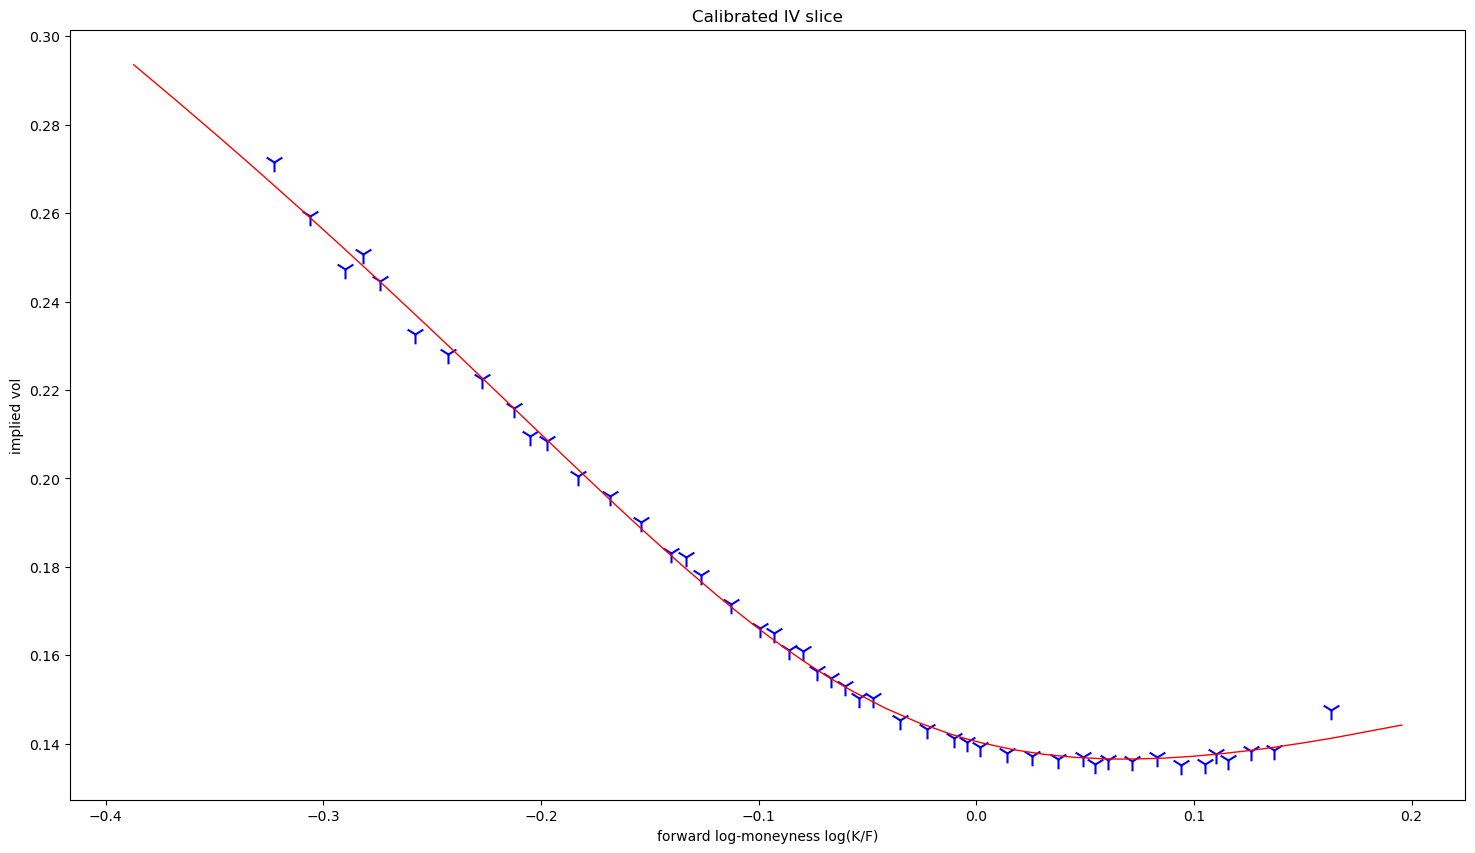

In [16]:
# we compute all the strikes
list_of_strikes=[]
for K in df.Strike:
    if K not in list_of_strikes:
        list_of_strikes.append(K)
list_of_strikes=np.sort(list_of_strikes)

IV_data = []
lm_data = []
# we compute the strikes available for calls or puts, and then compute IV
for K in list_of_strikes:
    call_empty=df[(df.Type=="Call") & (df.Strike==K)].empty
    put_empty=df[(df.Type=="Put") & (df.Strike==K)].empty
    if (K>=F): # we select call price if available
        if call_empty==0.0: # call price exist
            call_price=df[(df.Type=="Call") & (df.Strike==K)].Mid.values[0]
            vol_impli, iterations=volImplCallCore_Newton(tau, K, DF, F, call_price, initial_point='automatic', prix_tol = 1.e-3, max_iter=50)
            IV_data=np.append(IV_data, vol_impli)
            lm_data=np.append(lm_data, np.log(K/F))
    else: # we select put price if available
        if put_empty==0.0: # put price exist, we deduce call price by parity relation
            put_price=df[(df.Type=="Put") & (df.Strike==K)].Mid.values[0]
            call_price=put_price + DF*(F-K)
            vol_impli, iterations=volImplCallCore_Newton(tau, K, DF, F, call_price, initial_point='automatic', prix_tol = 1.e-3, max_iter=50)
            IV_data=np.append(IV_data, vol_impli)
            lm_data=np.append(lm_data, np.log(K/F))        
    
Total_Variance_data=IV_data**2*tau
# initial guess
a_init = np.min(IV_data**2*tau) /2
b_init = 0
rho_init = 0
k_0_init = 0 
sig_init = np.min(IV_data**2*tau) /2

SVIparameter_init    = np.array([a_init, b_init, rho_init, k_0_init, sig_init]) 

result=optimization.minimize(function_to_minimize_least_squares, args=(lm_data, Total_Variance_data), 
                             x0=SVIparameter_init, method='L-BFGS-B', tol=1E-10,
                             bounds=[(1E-5, np.max(Total_Variance_data)),
                                     (1E-3,1), 
                                     (-1 + 1e-3, 1 - 1e-3), 
                                     (2*np.min(lm_data),2*np.max(lm_data)), 
                                     (0.001, 1)])  

a, b , rho, k_0, sig = result['x']
print("Initial", SVIparameter_init)
print("Final", result['x'])

plt.figure(figsize=(18,10))
plt.title("Calibrated IV slice")
plt.xlabel("forward log-moneyness log(K/F)")
plt.ylabel("implied vol")
plt.plot(lm_data*1.2,np.sqrt(SVI(lm_data*1.2, a, b , rho, k_0, sig)/tau), lw=1, color="red")
plt.scatter(lm_data,IV_data, s=200, marker="1",color="blue")    